In [2]:
from datasets import two_moons
import matplotlib.pyplot as plt
import torch.utils.data as data
import torch
import zuko

In [3]:
samples, labels = two_moons(16384)

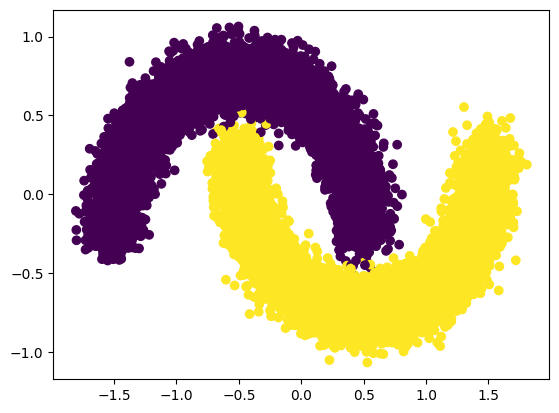

In [4]:
plt.scatter(*samples.T, c=labels)
plt.show()

In [5]:
trainset = data.TensorDataset(*two_moons(16384))
trainloader = data.DataLoader(trainset, batch_size=64, shuffle=True)

In [6]:
flow = zuko.flows.NSF(features=2, transforms=3, hidden_features=(64, 64))

In [7]:
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)

for epoch in range(8):
    losses = []

    for x, label in trainloader:
        loss = -flow().log_prob(x).mean()
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.detach())

    losses = torch.stack(losses)

    print(f"({epoch})", losses.mean().item(), "±", losses.std().item())

(0) 1.348099708557129 ± 0.24780811369419098
(1) 1.1515144109725952 ± 0.09292689710855484
(2) 1.1219602823257446 ± 0.0997709184885025
(3) 1.0990049839019775 ± 0.10634427517652512
(4) 1.085715889930725 ± 0.09701759368181229
(5) 1.0734961032867432 ± 0.09893500059843063
(6) 1.0646963119506836 ± 0.09073510766029358
(7) 1.059092402458191 ± 0.09966122359037399


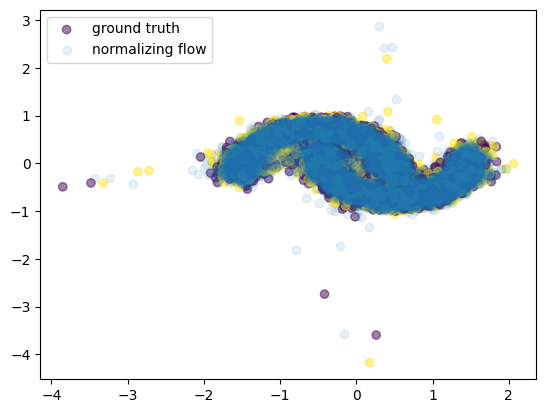

In [15]:
nf_samples = flow().sample((16384,))

plt.scatter(*samples.T, c=labels, alpha=0.5, label="ground truth")

plt.scatter(*nf_samples.T, alpha=0.1, label="normalizing flow")

plt.legend()
plt.show()